# Upload to hugging face

# Install necessary Libraries

In [1]:
!pip install pycocotools opencv-python matplotlib timm

In [1]:
import os
import shutil
import random

# ===== SOURCE (READ-ONLY) =====
SRC_BASE = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/train/train/train"
SRC_IMG = os.path.join(SRC_BASE, "image")
SRC_ANNO = os.path.join(SRC_BASE, "annos")

# ===== DESTINATION (WRITEABLE) =====
DEST_BASE = "/kaggle/working/train_subset"
DEST_IMG = os.path.join(DEST_BASE, "image")
DEST_ANNO = os.path.join(DEST_BASE, "annos")

# ===== CREATE OUTPUT DIR =====
os.makedirs(DEST_IMG, exist_ok=True)
os.makedirs(DEST_ANNO, exist_ok=True)

# ===== GET ALL IMAGES =====
all_images = sorted([f for f in os.listdir(SRC_IMG) if f.endswith(".jpg")])

# ===== SELECT HOW MANY YOU WANT =====
N = 100   # 🔥 change this (or use ALL)

# Option 1: subset
selected_images = random.sample(all_images, min(N, len(all_images)))

# Option 2 (uncomment to take ALL)
# selected_images = all_images

# ===== COPY =====
copied = 0
missing_annos = 0

for img_file in selected_images:
    base = os.path.splitext(img_file)[0]
    anno_file = base + ".json"

    img_src = os.path.join(SRC_IMG, img_file)
    anno_src = os.path.join(SRC_ANNO, anno_file)

    if os.path.exists(anno_src):
        shutil.copy(img_src, os.path.join(DEST_IMG, img_file))
        shutil.copy(anno_src, os.path.join(DEST_ANNO, anno_file))
        copied += 1
    else:
        missing_annos += 1

print(f"✅ Copied: {copied}")
print(f"⚠️ Missing annotations: {missing_annos}")
print(f"📁 Output folder: {DEST_BASE}")

✅ Copied: 100
⚠️ Missing annotations: 0
📁 Output folder: /kaggle/working/train_subset


In [2]:
import shutil

# Folder to zip
folder_path = "/kaggle/working/train_subset"

# Output zip file
zip_path = "/kaggle/working/train_subset.zip"

# Create zip
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)

print(f"✅ Zipped at: {zip_path}")

✅ Zipped at: /kaggle/working/train_subset.zip


# 1. Task 1: Multi-label Classification

## Dataset extraction

Above our goal is to convert image + JSOn annotations to proper clean classification dataset like:

- dataset/
  
      - train/
          - images/
          - labels.csv
  
      - val/
          - images/
          - labels.csv

We expect labels.csv to look like

image_name,coat,dress,vect,skirt,...
000001.jpg,0,1,0,0
000002.jpg,1,0,1,9

For Task1 we need:

- train/image
- train/annos
- validation/image
- validation/anno
  

### 1.1 Extract Categories from the dataset

In [2]:
import os
import json
from tqdm import tqdm

def extract_categories(anno_dir):

    categories = set()

    files = os.listdir(anno_dir)

    for file in tqdm(files):

        if not file.endswith(".json"):
            continue

        path = os.path.join(anno_dir, file)

        with open(path) as f:
            data = json.load(f)

        for key in data:

            if "item" not in key:
                continue

            item = data[key]

            if "category_name" in item:
                categories.add(item["category_name"])

    return sorted(list(categories))

In [3]:
train_anno_dir = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/train/train/train/annos"

CATEGORIES = extract_categories(train_anno_dir)

print("Number of categories:", len(CATEGORIES))
print("Categories found:\n")

for c in CATEGORIES:
    print(c)

100%|██████████| 191961/191961 [29:57<00:00, 106.78it/s]

Number of categories: 13
Categories found:

long sleeve dress
long sleeve outwear
long sleeve top
short sleeve dress
short sleeve outwear
short sleeve top
shorts
skirt
sling
sling dress
trousers
vest
vest dress


In [ ]:
val_anno_dir = "./validation/validation/validation/annos"

val_categories = extract_categories(val_anno_dir)

print("Validation categories:\n")

for c in val_categories:
    print(c)

### 1.2 Extracting Categories freq

In [4]:
os.chdir('/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd')

In [5]:
import os
import json
from collections import Counter
from tqdm import tqdm

train_anno_dir = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/train/train/train/annos"

category_counter = Counter()

files = os.listdir(train_anno_dir)

for file in tqdm(files):

    if not file.endswith(".json"):
        continue

    path = os.path.join(train_anno_dir, file)

    with open(path) as f:
        data = json.load(f)

    for key in data:

        if "item" not in key:
            continue

        category = data[key]["category_name"]

        category_counter[category] += 1

100%|██████████| 191961/191961 [03:51<00:00, 830.94it/s] 


In [6]:
print("Category frequencies:\n")

for cat, count in category_counter.most_common():
    print(cat, ":", count)

Category frequencies:

short sleeve top : 71645
trousers : 55387
shorts : 36616
long sleeve top : 36064
skirt : 30835
vest dress : 17949
short sleeve dress : 17211
vest : 16095
long sleeve outwear : 13457
long sleeve dress : 7907
sling dress : 6492
sling : 1985
short sleeve outwear : 543


In [7]:
TOP5 = [cat for cat, _ in category_counter.most_common(5)]

print("Top 5 categories:")
print(TOP5)

Top 5 categories:
['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']


In [8]:
label_map = {cat:i for i,cat in enumerate(TOP5)}

print("Label mapping:")

for k,v in label_map.items():
    print(k,"->",v)

Label mapping:
short sleeve top -> 0
trousers -> 1
shorts -> 2
long sleeve top -> 3
skirt -> 4


### 1.3 Generate Multi-label csv

In [ ]:
import pandas as pd

def build_labels(image_dir, anno_dir, output_csv):

    rows = []

    images = sorted(os.listdir(image_dir))

    for img in tqdm(images):

        anno_file = os.path.join(
            anno_dir,
            img.replace(".jpg",".json")
        )

        labels = [0]*5

        if os.path.exists(anno_file):

            with open(anno_file) as f:
                data = json.load(f)

            for key in data:

                if "item" not in key:
                    continue

                cat = data[key]["category_name"]

                if cat in label_map:
                    labels[label_map[cat]] = 1

        rows.append([img] + labels)

    columns = ["image"] + TOP5

    df = pd.DataFrame(rows, columns=columns)

    df.to_csv(output_csv, index=False)

    print("Saved:", output_csv)

#### 1.3.1 Create Train Labels

In [ ]:
build_labels(
    "./train/train/train/image",
    "./train/train/train/annos",
    "./train_labels_top5_new.csv"
)

#### 1.3.2 Create Validation Labels

In [ ]:
build_labels(
    "./validation/validation/validation/image",
    "./validation/validation/validation/annos",
    "./val_labels_top5_new.csv"
)

#### 1.3.3 Inspect Labels

In [9]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/mightyshashank/vr-csv/train_labels_top5_new.csv")
df.head()

,image,short sleeve top,trousers,shorts,long sleeve top,skirt
0,000001.jpg,1,1,0,0,0
1,000002.jpg,1,0,0,0,0
2,000003.jpg,0,0,0,0,0
3,000004.jpg,0,0,0,0,0
4,000005.jpg,0,0,0,0,0


### 1.4 Training

We use validation dataset for the following:
- model evaluation
- early stopping
- hyperparameter tuning

In [10]:
import torch

# Enable cuDNN auto-tuner for faster convolutions
torch.backends.cudnn.benchmark = True

#### 1.4.1 Imports

In [15]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import timm
import torch.nn as nn
from tqdm import tqdm

#### 1.4.2 Load Label CSV

In [12]:
train_df = pd.read_csv("/kaggle/input/datasets/mightyshashank/vr-csv/train_labels_top5_new.csv")
val_df = pd.read_csv("/kaggle/input/datasets/mightyshashank/vr-csv/val_labels_top5_new.csv")

#### 1.4.3 Dataset class and Image transforms

In [18]:
class FashionDataset(Dataset):

    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row["image"])

        # ---- SAFEGUARD AGAINST CORRUPTED IMAGES ----
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            print("Skipping corrupted image:", img_path)
            return self.__getitem__((idx+1) % len(self.df))

        labels = torch.tensor(row[1:].values.astype("float32"))

        if self.transform:
            image = self.transform(image)

        return image, labels

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

In [20]:
train_dataset = FashionDataset(
    train_df,
    "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/train/train/train/image",
    train_transform
)

val_dataset = FashionDataset(
    val_df,
    "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/validation/validation/validation/image",
    val_transform
)

#### 1.4.4 Dataset Loaders

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

#### 1.4.5 Training (Fine-tuning : EfficientNet_b0)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_efficientnet_b0_TL = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=5
)

model_efficientnet_b0_TL = model_efficientnet_b0_TL.to(device)

#### 1.4.6 Loss Function and Optimiser

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_efficientnet_b0_TL.parameters(),
    lr=1e-4
)

#### 1.4.7 Train function

In [16]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def train_epoch(model, loader):

    model.train()
    total_loss = 0

    for images, labels in tqdm(loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

/tmp/ipykernel_55/2135136295.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


#### 1.4.8 Validation Function

In [22]:
def validate(model, loader):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [23]:
torch.cuda.is_available()

True

#### 1.4.9 Training Loop (Efficient Net b0)

In [ ]:
EPOCHS = 5
best_val = float("inf")

for epoch in range(EPOCHS):

    train_loss = train_epoch(model_efficientnet_b0_TL, train_loader)
    val_loss = validate(model_efficientnet_b0_TL, val_loader)

    # minimal logging (prevents output memory growth)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # overwrite latest checkpoint (only one file)
    torch.save(
        model_efficientnet_b0_TL.state_dict(),
        "/kaggle/working/latest_checkpoint.pth"
    )

    # save best model only
    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            model_efficientnet_b0_TL.state_dict(),
            "/kaggle/working/best_model_efficientnet_b0_fine_tuned.pth"
        )

In [24]:
# ---- Load the saved EfficientNet model and evaluate ----

import torch
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

# recreate the same architecture used during training
model_efficientnet_b0_TL = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=5
)

# load saved weights
model_efficientnet_b0_TL.load_state_dict(
    torch.load(
        "/kaggle/working/best_model_efficientnet_b0_fine_tuned.pth",
        map_location=device
    )
)

model_efficientnet_b0_TL = model_efficientnet_b0_TL.to(device)

# switch to evaluation mode
model_efficientnet_b0_TL.eval()

# compute validation loss
val_loss = validate(model_efficientnet_b0_TL, val_loader)

print("Validation Loss (EfficientNet B0):", val_loss)

Validation Loss (EfficientNet B0): 0.2348902127659226


#### 1.4.10 Evaluation of the above Efficient Net model

In [13]:
model_efficientnet_b0_TL.load_state_dict(
    torch.load("/kaggle/working/best_model_efficientnet_b0_fine_tuned.pth")
)

model_efficientnet_b0_TL.eval()

NameError: name 'model_efficientnet_b0_TL' is not defined

In [ ]:
model_efficientnet_b0_TL.eval()

In [25]:
val_loss = validate(model_efficientnet_b0_TL, val_loader)

print("EfficientNet Final Validation Loss:", val_loss)

EfficientNet Final Validation Loss: 0.2348902127659226



====== EfficientNet-B0 (Fine-Tuned) Evaluation ======

Micro Metrics
Precision : 0.8377
Recall    : 0.7564
F1 Score  : 0.7949

Macro Metrics
Precision : 0.8255
Recall    : 0.7378
F1 Score  : 0.7784

ROC-AUC
Macro AUC : 0.9461

Per-Class AUC
Class 0: 0.9303
Class 1: 0.9789
Class 2: 0.9581
Class 3: 0.9275
Class 4: 0.9359


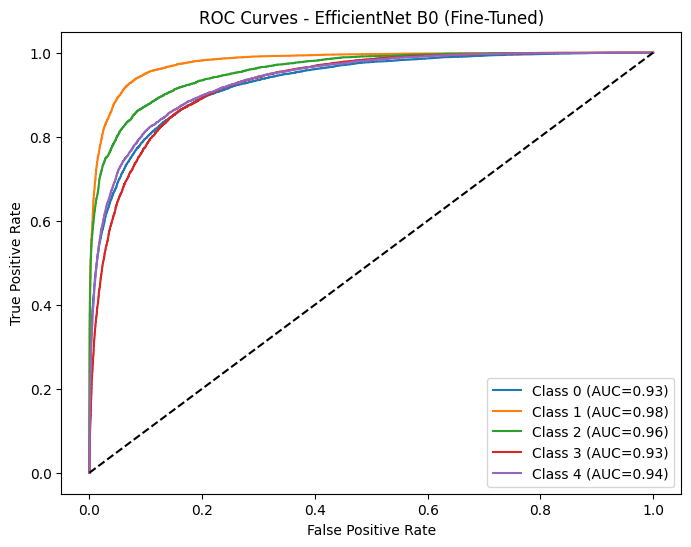

In [26]:
# =========================
# IMPORTS
# =========================
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD MODEL
# =========================
# model_efficientnet_b0_TL = timm.create_model(
#     "efficientnet_b0",
#     pretrained=True,
#     num_classes=5
# )

# model_efficientnet_b0_TL.load_state_dict(
#     torch.load("/kaggle/working/best_model_efficientnet_b0_fine_tuned.pth", map_location=device)
# )

# model_efficientnet_b0_TL = model_efficientnet_b0_TL.to(device)
# model_efficientnet_b0_TL.eval()

# =========================
# COLLECT PREDICTIONS
# =========================
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_efficientnet_b0_TL(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# =========================
# METRICS (PROJECT REQUIRED)
# =========================

# ---- MICRO ----
precision_micro = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall_micro    = recall_score(all_labels, all_preds, average="micro", zero_division=0)
f1_micro        = f1_score(all_labels, all_preds, average="micro", zero_division=0)

# ---- MACRO ----
precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall_macro    = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1_macro        = f1_score(all_labels, all_preds, average="macro", zero_division=0)

# ---- ROC-AUC (macro) ----
roc_auc_macro = roc_auc_score(all_labels, all_probs, average="macro")

# ---- PER CLASS AUC ----
per_class_auc = []
for i in range(all_labels.shape[1]):
    auc_i = roc_auc_score(all_labels[:, i], all_probs[:, i])
    per_class_auc.append(auc_i)

# =========================
# PRINT RESULTS
# =========================
print("\n====== EfficientNet-B0 (Fine-Tuned) Evaluation ======")

print("\nMicro Metrics")
print(f"Precision : {precision_micro:.4f}")
print(f"Recall    : {recall_micro:.4f}")
print(f"F1 Score  : {f1_micro:.4f}")

print("\nMacro Metrics")
print(f"Precision : {precision_macro:.4f}")
print(f"Recall    : {recall_macro:.4f}")
print(f"F1 Score  : {f1_macro:.4f}")

print("\nROC-AUC")
print(f"Macro AUC : {roc_auc_macro:.4f}")

print("\nPer-Class AUC")
for i, auc_val in enumerate(per_class_auc):
    print(f"Class {i}: {auc_val:.4f}")

# =========================
# ROC CURVES (REQUIRED)
# =========================
plt.figure(figsize=(8,6))

for i in range(all_labels.shape[1]):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={per_class_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - EfficientNet B0 (Fine-Tuned)")
plt.legend()
plt.show()

#### 1.4.11 Training (Fine-tuning : ResNet50)

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_resnet50_TL = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=5
)

model_resnet50_TL = model_resnet50_TL.to(device)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [29]:
optimizer = torch.optim.Adam(
    model_resnet50_TL.parameters(),
    lr=1e-4
)

In [31]:
EPOCHS = 5
best_val = float("inf")

final_val_loss = None

for epoch in range(EPOCHS):

    train_loss = train_epoch(model_resnet50_TL, train_loader)
    val_loss = validate(model_resnet50_TL, val_loader)

    final_val_loss = val_loss

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    torch.save(
        model_resnet50_TL.state_dict(),
        "/kaggle/working/latest_checkpoint_resnet50_fine_tuned.pth"
    )

    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            model_resnet50_TL.state_dict(),
            "/kaggle/working/best_model_resnet50_fine_tuned.pth"
        )

print("\nFinal ResNet50 Validation Loss:", final_val_loss)


  0%|          | 0/3000 [00:00<?, ?it/s]/tmp/ipykernel_55/2135136295.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 3000/3000 [27:37<00:00,  1.81it/s]


Epoch 1/5 | Train: 0.3313 | Val: 0.2563


100%|██████████| 3000/3000 [13:35<00:00,  3.68it/s]


Epoch 2/5 | Train: 0.2276 | Val: 0.2263


100%|██████████| 3000/3000 [13:24<00:00,  3.73it/s]


Epoch 3/5 | Train: 0.1896 | Val: 0.2255


100%|██████████| 3000/3000 [13:07<00:00,  3.81it/s]


Epoch 4/5 | Train: 0.1599 | Val: 0.2282


100%|██████████| 3000/3000 [13:07<00:00,  3.81it/s]


Epoch 5/5 | Train: 0.1353 | Val: 0.2393

Final ResNet50 Validation Loss: 0.23931509240810014



====== ResNet50 (Fine-Tuned) Evaluation ======

Micro Metrics
Precision : 0.8465
Recall    : 0.7529
F1 Score  : 0.7970

Macro Metrics
Precision : 0.8371
Recall    : 0.7344
F1 Score  : 0.7807

ROC-AUC
Macro AUC : 0.9490

Per-Class AUC
Class 0: 0.9340
Class 1: 0.9796
Class 2: 0.9606
Class 3: 0.9312
Class 4: 0.9393


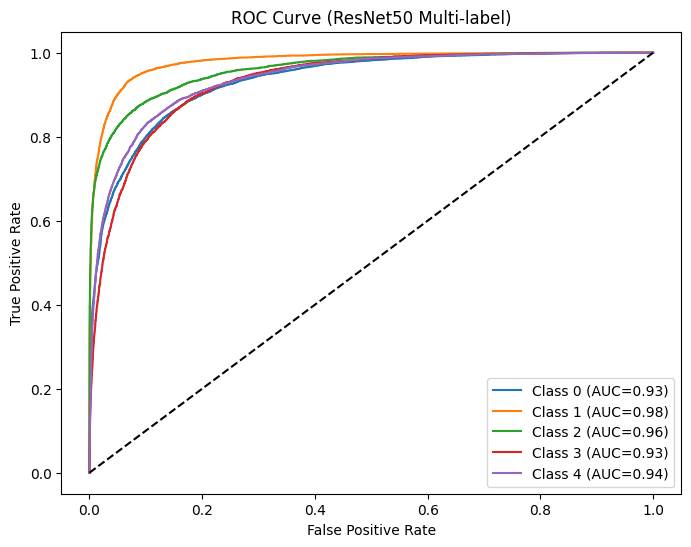

In [33]:
# Metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Load best ResNet50 model
model_resnet50_TL.load_state_dict(
    torch.load("/kaggle/working/best_model_resnet50_fine_tuned.pth")
)

model_resnet50_TL.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet50_TL(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


# ------------------------
# Metrics
# ------------------------

# Micro
precision_micro = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall_micro    = recall_score(all_labels, all_preds, average="micro", zero_division=0)
f1_micro        = f1_score(all_labels, all_preds, average="micro", zero_division=0)

# Macro
precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall_macro    = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1_macro        = f1_score(all_labels, all_preds, average="macro", zero_division=0)

# Macro AUC
roc_auc_macro = roc_auc_score(all_labels, all_probs, average="macro")

# Per-class AUC
per_class_auc = []
for i in range(all_labels.shape[1]):
    auc_i = roc_auc_score(all_labels[:, i], all_probs[:, i])
    per_class_auc.append(auc_i)


# ------------------------
# Print Results
# ------------------------

print("\n====== ResNet50 (Fine-Tuned) Evaluation ======")

print("\nMicro Metrics")
print(f"Precision : {precision_micro:.4f}")
print(f"Recall    : {recall_micro:.4f}")
print(f"F1 Score  : {f1_micro:.4f}")

print("\nMacro Metrics")
print(f"Precision : {precision_macro:.4f}")
print(f"Recall    : {recall_macro:.4f}")
print(f"F1 Score  : {f1_macro:.4f}")

print("\nROC-AUC")
print(f"Macro AUC : {roc_auc_macro:.4f}")

print("\nPer-Class AUC")
for i, auc_val in enumerate(per_class_auc):
    print(f"Class {i}: {auc_val:.4f}")


# ------------------------
# ROC Curve
# ------------------------

plt.figure(figsize=(8,6))

for i in range(all_labels.shape[1]):

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={per_class_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ResNet50 Multi-label)")
plt.legend()

plt.show()

#### 1.4.11 Training (Fine-tuning : MobileNetV3)

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_mobilenetv3_TL = timm.create_model(
    "mobilenetv3_large_100",
    pretrained=True,
    num_classes=5
)

model_mobilenetv3_TL = model_mobilenetv3_TL.to(device)

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

In [36]:
import torch.optim as optim

optimizer = optim.AdamW(
    model_mobilenetv3_TL.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [37]:
EPOCHS = 5
best_val = float("inf")

final_val_loss = None

for epoch in range(EPOCHS):

    train_loss = train_epoch(model_mobilenetv3_TL, train_loader)
    val_loss = validate(model_mobilenetv3_TL, val_loader)

    final_val_loss = val_loss

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    torch.save(
        model_mobilenetv3_TL.state_dict(),
        "/kaggle/working/latest_checkpoint_mobilenetv3_fine_tuned.pth"
    )

    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            model_mobilenetv3_TL.state_dict(),
            "/kaggle/working/best_model_mobilenetv3_fine_tuned.pth"
        )

print("\nFinal MobileNetV3 Validation Loss:", final_val_loss)

  0%|          | 0/3000 [00:00<?, ?it/s]/tmp/ipykernel_55/2135136295.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 3000/3000 [14:40<00:00,  3.41it/s]


Epoch 1/5 | Train: 0.3748 | Val: 0.2880


100%|██████████| 3000/3000 [13:11<00:00,  3.79it/s]


Epoch 2/5 | Train: 0.2503 | Val: 0.2600


100%|██████████| 3000/3000 [13:06<00:00,  3.81it/s]


Epoch 3/5 | Train: 0.2032 | Val: 0.2525


100%|██████████| 3000/3000 [12:43<00:00,  3.93it/s]


Epoch 4/5 | Train: 0.1671 | Val: 0.2618


100%|██████████| 3000/3000 [12:53<00:00,  3.88it/s]


Epoch 5/5 | Train: 0.1364 | Val: 0.2783

Final MobileNetV3 Validation Loss: 0.2782550223438332



====== MobileNetV3 (Fine-Tuned) Evaluation ======

Micro Metrics
Precision : 0.8112
Recall    : 0.7364
F1 Score  : 0.7720

Macro Metrics
Precision : 0.7961
Recall    : 0.7172
F1 Score  : 0.7541

ROC-AUC
Macro AUC : 0.9370

Per-Class AUC
Class 0: 0.9164
Class 1: 0.9741
Class 2: 0.9489
Class 3: 0.9172
Class 4: 0.9282


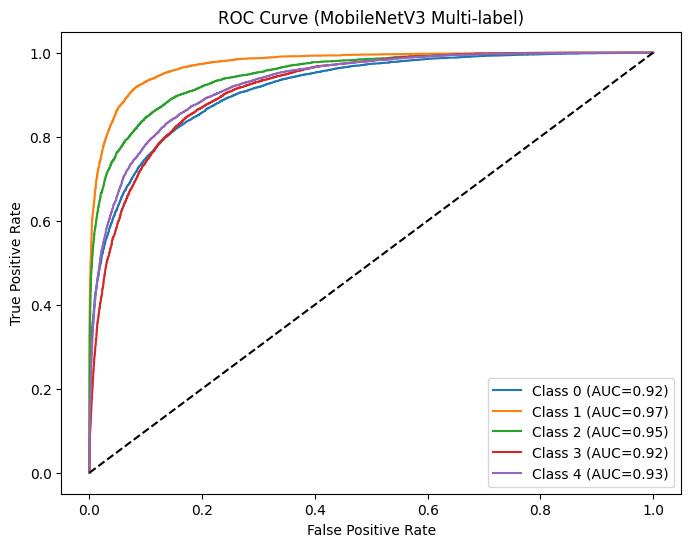

In [39]:
# Metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Load best MobileNetV3 model
model_mobilenetv3_TL.load_state_dict(
    torch.load("/kaggle/working/best_model_mobilenetv3_fine_tuned.pth")
)

model_mobilenetv3_TL.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_mobilenetv3_TL(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


# ------------------------
# Metrics
# ------------------------

# Micro
precision_micro = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall_micro    = recall_score(all_labels, all_preds, average="micro", zero_division=0)
f1_micro        = f1_score(all_labels, all_preds, average="micro", zero_division=0)

# Macro
precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall_macro    = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1_macro        = f1_score(all_labels, all_preds, average="macro", zero_division=0)

# Macro AUC
roc_auc_macro = roc_auc_score(all_labels, all_probs, average="macro")

# Per-class AUC
per_class_auc = []
for i in range(all_labels.shape[1]):
    auc_i = roc_auc_score(all_labels[:, i], all_probs[:, i])
    per_class_auc.append(auc_i)


# ------------------------
# Print Results
# ------------------------

print("\n====== MobileNetV3 (Fine-Tuned) Evaluation ======")

print("\nMicro Metrics")
print(f"Precision : {precision_micro:.4f}")
print(f"Recall    : {recall_micro:.4f}")
print(f"F1 Score  : {f1_micro:.4f}")

print("\nMacro Metrics")
print(f"Precision : {precision_macro:.4f}")
print(f"Recall    : {recall_macro:.4f}")
print(f"F1 Score  : {f1_macro:.4f}")

print("\nROC-AUC")
print(f"Macro AUC : {roc_auc_macro:.4f}")

print("\nPer-Class AUC")
for i, auc_val in enumerate(per_class_auc):
    print(f"Class {i}: {auc_val:.4f}")


# ------------------------
# ROC Curve
# ------------------------

plt.figure(figsize=(8,6))

for i in range(all_labels.shape[1]):

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={per_class_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (MobileNetV3 Multi-label)")
plt.legend()

plt.show()

#### 1.4.12 Training (From Scratch: Efficient Net b0)

In [40]:
import torch
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

model_efficientnet_b0_scratch = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=5
)

# use both GPUs if available
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model_efficientnet_b0_scratch = torch.nn.DataParallel(model_efficientnet_b0_scratch)

model_efficientnet_b0_scratch = model_efficientnet_b0_scratch.to(device)

Using 2 GPUs


In [41]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_efficientnet_b0_scratch.parameters(),
    lr=3e-4
)

In [42]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_efficientnet_b0_scratch.parameters(),
    lr=3e-4
)

In [ ]:
#  Training loop

EPOCHS = 5
best_val = float("inf")

for epoch in range(EPOCHS):

    train_loss = train_epoch(model_efficientnet_b0_scratch, train_loader)
    val_loss = validate(model_efficientnet_b0_scratch, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # overwrite latest checkpoint
    torch.save(
        model_efficientnet_b0_scratch.state_dict(),
        "/kaggle/working/latest_checkpoint_scratch_efficient_net_b0.pth"
    )

    # save best model
    if val_loss < best_val:
        best_val = val_loss

        torch.save(
            model_efficientnet_b0_scratch.state_dict(),
            "/kaggle/working/best_model_efficientnet_b0_scratch.pth"
        )

  0%|          | 0/3000 [00:00<?, ?it/s]/tmp/ipykernel_55/2135136295.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
 26%|██▌       | 775/3000 [48:21<2:17:12,  3.70s/it]

Micro vs Macro metrics

Micro metrics : 
- Combine all predictions from all classes together.
- They treat every individual label equally.
- A drawback being its dominated by frequent classes.


Macro Metrics :
- They computes the metrics separately for each class.
- Then average them, every class contributes equally regardless of frequency.
- So its good for checking performance on rare classes.

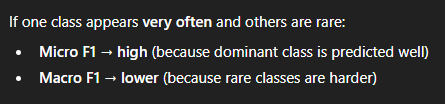

In [1]:
print("Hello")

Hello


In [ ]:
# Metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Load best model
model_efficientnet_b0_scratch.load_state_dict(
    torch.load("/kaggle/working/best_model_efficientnet_b0_scratch.pth")
)

model_efficientnet_b0_scratch.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_efficientnet_b0_scratch(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


# ------------------------
# Metrics
# ------------------------

precision_micro = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall_micro = recall_score(all_labels, all_preds, average="micro", zero_division=0)
f1_micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)

precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

roc_auc = roc_auc_score(all_labels, all_probs, average="macro")


print("\nFinal Evaluation Metrics")
print("----------------------------")
print(f"Validation Loss : {best_val:.4f}")

print("\nMicro Metrics")
print(f"Precision : {precision_micro:.4f}")
print(f"Recall    : {recall_micro:.4f}")
print(f"F1 Score  : {f1_micro:.4f}")

print("\nMacro Metrics")
print(f"Precision : {precision_macro:.4f}")
print(f"Recall    : {recall_macro:.4f}")
print(f"F1 Score  : {f1_macro:.4f}")

print("\nROC-AUC Score :", roc_auc)


# ------------------------
# ROC Curve
# ------------------------

plt.figure(figsize=(8,6))

for i in range(all_labels.shape[1]):

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])

    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-label)")
plt.legend()

plt.show()

#### 1.4.13 Training (From Scratch: ResNet-50)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_resnet50_scratch = timm.create_model(
    "resnet50",
    pretrained=False,
    num_classes=5
)

# use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model_resnet50_scratch = torch.nn.DataParallel(model_resnet50_scratch)

model_resnet50_scratch = model_resnet50_scratch.to(device)

In [ ]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_resnet50_scratch.parameters(),
    lr=3e-4
)

In [ ]:
EPOCHS = 5
best_val = float("inf")

final_val_loss = None

for epoch in range(EPOCHS):

    train_loss = train_epoch(model_resnet50_scratch, train_loader)
    val_loss = validate(model_resnet50_scratch, val_loader)

    final_val_loss = val_loss

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    torch.save(
        model_resnet50_scratch.state_dict(),
        "/kaggle/working/latest_checkpoint_resnet50_scratch.pth"
    )

    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            model_resnet50_scratch.state_dict(),
            "/kaggle/working/best_model_resnet50_scratch.pth"
        )

print("\nFinal ResNet50 Scratch Validation Loss:", final_val_loss)

In [ ]:
# Metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Load best ResNet50 Scratch model
model_resnet50_scratch.load_state_dict(
    torch.load("/kaggle/working/best_model_resnet50_scratch.pth")
)

model_resnet50_scratch.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet50_scratch(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


# ------------------------
# Metrics
# ------------------------

precision_micro = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall_micro = recall_score(all_labels, all_preds, average="micro", zero_division=0)
f1_micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)

precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

roc_auc = roc_auc_score(all_labels, all_probs, average="macro")


print("\nFinal Evaluation Metrics (ResNet50 Scratch)")
print("---------------------------------------------")
print(f"Validation Loss : {best_val:.4f}")

print("\nMicro Metrics")
print(f"Precision : {precision_micro:.4f}")
print(f"Recall    : {recall_micro:.4f}")
print(f"F1 Score  : {f1_micro:.4f}")

print("\nMacro Metrics")
print(f"Precision : {precision_macro:.4f}")
print(f"Recall    : {recall_macro:.4f}")
print(f"F1 Score  : {f1_macro:.4f}")

print("\nROC-AUC Score :", roc_auc)


# ------------------------
# ROC Curve
# ------------------------

plt.figure(figsize=(8,6))

for i in range(all_labels.shape[1]):

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ResNet50 Scratch Multi-label)")
plt.legend()

plt.show()

#### 1.4.14 Training (From Scratch: MobileNet V3)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_mobilenetv3_scratch = timm.create_model(
    "mobilenetv3_large_100",
    pretrained=False,
    num_classes=5
)

# use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model_mobilenetv3_scratch = torch.nn.DataParallel(model_mobilenetv3_scratch)

model_mobilenetv3_scratch = model_mobilenetv3_scratch.to(device)

In [ ]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_mobilenetv3_scratch.parameters(),
    lr=3e-4
)

In [ ]:
EPOCHS = 5
best_val = float("inf")

final_val_loss = None

for epoch in range(EPOCHS):

    train_loss = train_epoch(model_mobilenetv3_scratch, train_loader)
    val_loss = validate(model_mobilenetv3_scratch, val_loader)

    final_val_loss = val_loss

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # overwrite latest checkpoint
    torch.save(
        model_mobilenetv3_scratch.state_dict(),
        "/kaggle/working/latest_checkpoint_mobilenetv3_scratch.pth"
    )

    # save best model
    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            model_mobilenetv3_scratch.state_dict(),
            "/kaggle/working/best_model_mobilenetv3_scratch.pth"
        )

print("\nFinal MobileNetV3 Scratch Validation Loss:", final_val_loss)

In [ ]:
# Metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Load best MobileNetV3 Scratch model
model_mobilenetv3_scratch.load_state_dict(
    torch.load("/kaggle/working/best_model_mobilenetv3_scratch.pth")
)

model_mobilenetv3_scratch.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_mobilenetv3_scratch(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


# ------------------------
# Metrics
# ------------------------

precision_micro = precision_score(all_labels, all_preds, average="micro", zero_division=0)
recall_micro = recall_score(all_labels, all_preds, average="micro", zero_division=0)
f1_micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)

precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

roc_auc = roc_auc_score(all_labels, all_probs, average="macro")


print("\nFinal Evaluation Metrics (MobileNetV3 Scratch)")
print("-----------------------------------------------")
print(f"Validation Loss : {best_val:.4f}")

print("\nMicro Metrics")
print(f"Precision : {precision_micro:.4f}")
print(f"Recall    : {recall_micro:.4f}")
print(f"F1 Score  : {f1_micro:.4f}")

print("\nMacro Metrics")
print(f"Precision : {precision_macro:.4f}")
print(f"Recall    : {recall_macro:.4f}")
print(f"F1 Score  : {f1_macro:.4f}")

print("\nROC-AUC Score :", roc_auc)


# ------------------------
# ROC Curve
# ------------------------

plt.figure(figsize=(8,6))

for i in range(all_labels.shape[1]):

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (MobileNetV3 Scratch Multi-label)")
plt.legend()

plt.show()

# 2. Detection & Segmentation

In [ ]:
!pip install ultralytics segmentation-models-pytorch torchmetrics -q

In [ ]:
import os, json, cv2, yaml
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

In [ ]:
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE   = 512
NUM_CLASSES = 5   # reuses label_map and TOP5 from Section 1

TRAIN_IMG  = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/train/train/train/image"
TRAIN_ANNO = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/train/train/train/annos"
VAL_IMG    = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/validation/validation/validation/image"
VAL_ANNO   = "/kaggle/input/datasets/mightyshashank/vr-project-1-dataset-non-pwd/validation/validation/validation/annos"

train_df = pd.read_csv("/kaggle/input/private-dataset/train_labels_top5_new.csv")
val_df   = pd.read_csv("/kaggle/input/private-dataset/val_labels_top5_new.csv")

In [ ]:
CLASS_COLS = list(label_map.keys())

def stratified_sample(df, cols, n_per_class):
    selected = set()
    for col in cols:
        idxs = df[df[col] == 1].index.tolist()
        selected.update(idxs[:n_per_class])
    return df.loc[sorted(selected)].reset_index(drop=True)

train_df_det = stratified_sample(train_df, CLASS_COLS, n_per_class=600)
val_df_det   = stratified_sample(val_df,   CLASS_COLS, n_per_class=150)

print(f"Train subset : {len(train_df_det)} images")
print(f"Val   subset : {len(val_df_det)}   images")
print("\nPer-class counts (train):")
print(train_df_det[CLASS_COLS].sum().to_string())

In [ ]:
def parse_anno(img_name, anno_dir, label_map):
    path = os.path.join(anno_dir, img_name.replace(".jpg", ".json"))
    items = []
    if not os.path.exists(path):
        return items
    with open(path) as f:
        data = json.load(f)
    for key in data:
        if "item" not in key:
            continue
        item = data[key]
        cat  = item.get("category_name", "")
        if cat not in label_map:
            continue
        bbox = item.get("bounding_box", None)
        segs = item.get("segmentation", [])
        if bbox is None or not segs:
            continue
        items.append({"label": label_map[cat], "bbox": bbox, "segmentation": segs})
    return items

In [ ]:
def poly_to_mask(segmentation, H, W):
    mask = np.zeros((H, W), dtype=np.uint8)
    for poly in segmentation:
        pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask

def collate_fn(batch):
    return tuple(zip(*batch))

### 2.1 Mask R-CNN (Transfer Learning)

In [ ]:
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn  import MaskRCNNPredictor

class MRCNNDataset(Dataset):
    def __init__(self, df, img_dir, anno_dir, size=IMG_SIZE):
        self.df = df; self.img_dir = img_dir
        self.anno_dir = anno_dir; self.size = size

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image"]
        img = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")
        W, H = img.size
        img  = img.resize((self.size, self.size))
        img_t = TF.to_tensor(img)
        sx, sy = self.size / W, self.size / H

        boxes, labels, masks = [], [], []
        for ann in parse_anno(img_name, self.anno_dir, label_map):
            x1, y1, x2, y2 = [c * s for c, s in zip(ann["bbox"], [sx, sy, sx, sy])]
            if x2 <= x1 or y2 <= y1:
                continue
            sc = []
            for poly in ann["segmentation"]:
                # fix: scale as float, then cast to int32
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                pts[:, 0] *= sx; pts[:, 1] *= sy
                sc.append(pts.astype(np.int32).flatten().tolist())
            boxes.append([x1, y1, x2, y2])
            labels.append(ann["label"] + 1)
            masks.append(poly_to_mask(sc, self.size, self.size))

        if len(boxes) == 0:
            t = {"boxes":  torch.zeros((0, 4), dtype=torch.float32),
                 "labels": torch.zeros((0,),   dtype=torch.int64),
                 "masks":  torch.zeros((0, self.size, self.size), dtype=torch.uint8)}
        else:
            t = {"boxes":  torch.tensor(boxes,          dtype=torch.float32),
                 "labels": torch.tensor(labels,         dtype=torch.int64),
                 "masks":  torch.tensor(np.stack(masks), dtype=torch.uint8)}
        t["image_id"] = torch.tensor([idx])
        return img_t, t

train_mrcnn_dl = DataLoader(MRCNNDataset(train_df_det, TRAIN_IMG, TRAIN_ANNO),
                             batch_size=4, shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_mrcnn_dl   = DataLoader(MRCNNDataset(val_df_det,   VAL_IMG,   VAL_ANNO),
                             batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=2)

In [ ]:
def get_maskrcnn():
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_f  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor  = FastRCNNPredictor(in_f, NUM_CLASSES + 1)
    in_m  = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_m, 256, NUM_CLASSES + 1)
    return model

In [ ]:
maskrcnn  = get_maskrcnn().to(DEVICE)
opt_mrcnn = torch.optim.Adam([p for p in maskrcnn.parameters() if p.requires_grad], lr=1e-4)

EPOCHS = 5
best_mrcnn_loss = float("inf")

for epoch in range(EPOCHS):
    maskrcnn.train()
    total = 0
    for imgs, targets in train_mrcnn_dl:
        imgs    = [i.to(DEVICE) for i in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss    = sum(maskrcnn(imgs, targets).values())
        opt_mrcnn.zero_grad(); loss.backward(); opt_mrcnn.step()
        total  += loss.item()
    avg = total / len(train_mrcnn_dl)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg:.4f}")
    if avg < best_mrcnn_loss:
        best_mrcnn_loss = avg
        torch.save(maskrcnn.state_dict(), "/kaggle/working/best_maskrcnn.pth")

In [ ]:
from torchmetrics.detection import MeanAveragePrecision

maskrcnn.load_state_dict(torch.load("/kaggle/working/best_maskrcnn.pth"))
maskrcnn.eval()

metric_mrcnn  = MeanAveragePrecision(iou_type="segm")
iou_cls_mrcnn = [[] for _ in range(NUM_CLASSES)]

with torch.no_grad():
    for imgs, targets in val_mrcnn_dl:
        imgs  = [i.to(DEVICE) for i in imgs]
        preds = maskrcnn(imgs)

        # threshold float masks → uint8 before metric update
        preds_fixed = []
        for p in preds:
            preds_fixed.append({
                "boxes":  p["boxes"].cpu(),
                "scores": p["scores"].cpu(),
                "labels": p["labels"].cpu(),
                "masks":  (p["masks"].squeeze(1).cpu() > 0.5).to(torch.uint8)
            })

        targets_fixed = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric_mrcnn.update(preds_fixed, targets_fixed)

        for pred, tgt in zip(preds_fixed, targets_fixed):
            for pm, pl in zip(pred["masks"], pred["labels"]):
                pb = pm.numpy()
                c  = pl.item() - 1
                if not (0 <= c < NUM_CLASSES): continue
                gt = tgt["masks"][tgt["labels"] == (c + 1)].numpy()
                if len(gt) == 0: continue
                iou_cls_mrcnn[c].append(
                    max((pb & g).sum() / ((pb | g).sum() + 1e-6) for g in gt))

res_mrcnn     = metric_mrcnn.compute()
per_iou_mrcnn = [np.mean(v) if v else 0.0 for v in iou_cls_mrcnn]
miou_mrcnn    = np.mean(per_iou_mrcnn)
dice_mrcnn    = np.mean([2 * iou / (1 + iou) for iou in per_iou_mrcnn])

In [ ]:
print("Mask R-CNN Results")
print(f"mAP@[0.5:0.95] (segm) : {res_mrcnn['map'].item():.4f}")
print(f"mAP@0.50       (segm) : {res_mrcnn['map_50'].item():.4f}")
print(f"mIoU                  : {miou_mrcnn:.4f}")
print(f"Dice (macro)          : {dice_mrcnn:.4f}")
print(f"Per-class IoU         : {[f'{v:.3f}' for v in per_iou_mrcnn]}")

### 2.2 YOLO (Transfer Learning — YOLOv8s-seg)

In [ ]:
import yaml
from ultralytics import YOLO

YOLO_DIR = "/kaggle/working/yolo_data"

In [ ]:
def build_yolo_split(df, img_dir, anno_dir, split):
    img_out   = f"{YOLO_DIR}/images/{split}"
    label_out = f"{YOLO_DIR}/labels/{split}"
    os.makedirs(img_out,   exist_ok=True)
    os.makedirs(label_out, exist_ok=True)

    for _, row in df.iterrows():
        name = row["image"]
        src  = os.path.join(img_dir, name)
        if not os.path.exists(src):
            continue

        # symlink image — zero extra disk usage
        stem    = os.path.splitext(name)[0]
        dst_img = f"{img_out}/{stem}.jpg"
        if not os.path.exists(dst_img):
            os.symlink(src, dst_img)

        # read image dims for normalisation only (no copy)
        img = cv2.imread(src)
        if img is None:
            continue
        H, W = img.shape[:2]

        lines = []
        for ann in parse_anno(name, anno_dir, label_map):
            cls      = ann["label"]
            pts_flat = []
            for poly in ann["segmentation"]:
                arr = np.array(poly, dtype=np.float32).reshape(-1, 2)
                arr[:, 0] /= W; arr[:, 1] /= H
                pts_flat.extend(arr.flatten().tolist())
            if pts_flat:
                lines.append(f"{cls} " + " ".join(f"{v:.6f}" for v in pts_flat))

        with open(f"{label_out}/{stem}.txt", "w") as f:
            f.write("\n".join(lines))

build_yolo_split(train_df_det, TRAIN_IMG, TRAIN_ANNO, "train")
build_yolo_split(val_df_det,   VAL_IMG,   VAL_ANNO,   "val")

yaml.dump({"path": YOLO_DIR, "train": "images/train", "val": "images/val",
           "nc": NUM_CLASSES, "names": list(label_map.keys())},
          open(f"{YOLO_DIR}/data.yaml", "w"))
print("YOLO dataset ready (images symlinked, no copy)")

In [ ]:
os.chdir("/kaggle/working")

In [ ]:
yolo_model = YOLO("yolov8s-seg.pt")
yolo_model.train(
    data     = f"{YOLO_DIR}/data.yaml",
    epochs   = 20,          
    imgsz    = 416,          # was 512, saves memory
    batch    = 8,
    device   = 0 if torch.cuda.is_available() else "cpu",
    project  = "/kaggle/working",
    name     = "yolo_seg_v2",
    exist_ok = True,
    patience = 10,           # early stopping
    overlap_mask = True,     # helps with overlapping clothing
    mask_ratio   = 2,        # finer masks
)

In [ ]:
val_res_yolo = yolo_model.val(data=f"{YOLO_DIR}/data.yaml")

map_box_yolo = val_res_yolo.box.map
map_seg_yolo = val_res_yolo.seg.map

In [ ]:
print("YOLO Results")
print(f"Box  mAP@[0.5:0.95] : {map_box_yolo:.4f}")
print(f"Seg  mAP@[0.5:0.95] : {map_seg_yolo:.4f}")
print(f"Box  mAP@0.50       : {val_res_yolo.box.map50:.4f}")
print(f"Seg  mAP@0.50       : {val_res_yolo.seg.map50:.4f}")

### 2.3 U-Net (Transfer Learning — ResNet34 encoder)

In [ ]:
import segmentation_models_pytorch as smp

class UNetDataset(Dataset):
    def __init__(self, df, img_dir, anno_dir, size=IMG_SIZE, aug=None):
        self.df = df; self.img_dir = img_dir
        self.anno_dir = anno_dir; self.size = size; self.aug = aug

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image"]
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))

        W_orig, H_orig = Image.open(os.path.join(self.img_dir, img_name)).size
        sx, sy = self.size / W_orig, self.size / H_orig

        seg_mask = np.zeros((self.size, self.size), dtype=np.int64)
        for ann in parse_anno(img_name, self.anno_dir, label_map):
            sc = []
            for poly in ann["segmentation"]:
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                pts[:, 0] *= sx; pts[:, 1] *= sy
                sc.append(pts.astype(np.int32).flatten().tolist())
            m = poly_to_mask(sc, self.size, self.size)
            seg_mask[m == 1] = ann["label"] + 1

        if self.aug:
            out    = self.aug(image=img, mask=seg_mask.astype(np.uint8))
            img_t  = out["image"].float()
            mask_t = torch.tensor(out["mask"], dtype=torch.long)
        else:
            img_t  = TF.to_tensor(img)
            mask_t = torch.tensor(seg_mask, dtype=torch.long)

        return img_t, mask_t

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.Affine(translate_percent=0.1, scale=(0.8, 1.2), rotate=(-15, 15), p=0.5),
    A.GridDistortion(p=0.2),
    A.CoarseDropout(num_holes_range=(4, 8), hole_height_range=(16, 32),
                    hole_width_range=(16, 32), p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [ ]:
train_df_unet = stratified_sample(train_df, CLASS_COLS, n_per_class=2000)
val_df_unet   = stratified_sample(val_df,   CLASS_COLS, n_per_class=200)

print(f"U-Net Train: {len(train_df_unet)} | Val: {len(val_df_unet)}")

train_unet_dl = DataLoader(UNetDataset(train_df_unet, TRAIN_IMG, TRAIN_ANNO, aug=train_aug),
                            batch_size=8, shuffle=True,  num_workers=2)
val_unet_dl   = DataLoader(UNetDataset(val_df_unet,   VAL_IMG,   VAL_ANNO,  aug=val_aug),
                            batch_size=8, shuffle=False, num_workers=2)

In [ ]:
unet = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet",
                in_channels=3, classes=NUM_CLASSES + 1).to(DEVICE)

# class weights: downweight background (class 0), upweight clothing
weights = torch.tensor([0.2, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=torch.float32).to(DEVICE)
ce_loss   = torch.nn.CrossEntropyLoss(weight=weights)
dice_loss = smp.losses.DiceLoss(mode="multiclass")

def combined_loss(pred, mask):
    return 0.5 * dice_loss(pred, mask) + 0.5 * ce_loss(pred, mask)
    
opt_unet  = torch.optim.Adam(unet.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt_unet, T_max=20)

In [ ]:
EPOCHS = 5
best_unet_loss = float("inf")

for epoch in range(EPOCHS):
    unet.train()
    train_total = 0
    for imgs, masks in train_unet_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = combined_loss(unet(imgs), masks)
        opt_unet.zero_grad(); loss.backward(); opt_unet.step()
        train_total += loss.item()

    # validate each epoch
    unet.eval()
    val_total = 0
    with torch.no_grad():
        for imgs, masks in val_unet_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            val_total += combined_loss(unet(imgs), masks).item()

    scheduler.step()
    t_avg = train_total / len(train_unet_dl)
    v_avg = val_total   / len(val_unet_dl)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {t_avg:.4f} | Val: {v_avg:.4f}")

    if v_avg < best_unet_loss:
        best_unet_loss = v_avg
        torch.save(unet.state_dict(), "/kaggle/working/best_unet.pth")

In [ ]:
from scipy import ndimage

unet.load_state_dict(torch.load("/kaggle/working/best_unet.pth"))
unet.eval()

iou_cls_unet  = [[] for _ in range(NUM_CLASSES)]
dice_cls_unet = [[] for _ in range(NUM_CLASSES)]

with torch.no_grad():
    for imgs, masks in val_unet_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = unet(imgs).argmax(dim=1)
        for c in range(NUM_CLASSES):
            p = (preds == c + 1).cpu().numpy()
            g = (masks == c + 1).cpu().numpy()
            inter = (p & g).sum(); union = (p | g).sum()
            if union > 0:
                iou_cls_unet[c].append(inter / (union + 1e-6))
                dice_cls_unet[c].append(2 * inter / (p.sum() + g.sum() + 1e-6))

In [ ]:
per_iou_unet  = [np.mean(v) if v else 0.0 for v in iou_cls_unet]
per_dice_unet = [np.mean(v) if v else 0.0 for v in dice_cls_unet]
miou_unet = np.mean(per_iou_unet)
dice_unet = np.mean(per_dice_unet)

print("U-Net Results")
print(f"mIoU         : {miou_unet:.4f}")
print(f"Dice (macro) : {dice_unet:.4f}")
print(f"Per-class IoU: {[f'{v:.3f}' for v in per_iou_unet]}")

In [ ]:
# Instance post-processing via connected components
def unet_instances(pred_mask):
    instances = []
    for c in range(NUM_CLASSES):
        binary = (pred_mask == c + 1).astype(np.uint8)
        labeled, n = ndimage.label(binary)
        for i in range(1, n + 1):
            comp = (labeled == i)
            ys, xs = np.where(comp)
            if len(xs) < 10: continue
            instances.append({
                "bbox":  [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())],
                "mask":  comp.astype(np.uint8), "label": c})
    return instances

### 2.4 Summary Table

In [ ]:
summary = pd.DataFrame({
    "Model"          : ["Mask R-CNN", "YOLOv8s-seg", "U-Net"],
    "mAP@[0.5:0.95]" : [f"{res_mrcnn['map'].item():.4f}", f"{map_seg_yolo:.4f}", "N/A"],
    "mIoU"           : [f"{miou_mrcnn:.4f}", "—", f"{miou_unet:.4f}"],
    "Dice (macro)"   : [f"{dice_mrcnn:.4f}", "—", f"{dice_unet:.4f}"],
})
print(summary.to_string(index=False))